<a href="https://colab.research.google.com/github/sashajjjoy/quant/blob/main/Revenue%20growth%20and%20profitability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Is growth rev depend on margin? *in successful companies like rev>5 bln rub) Is it connected with size of the company or age or industry? Is effect exist?

проверим линейную зависимость компании выше 5 млрд выручка за 2024 год и рост больше 0% по сравнению с предыдущим

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set(style="whitegrid", context="talk")

# -----------------------------
# 1. Загрузка данных
# -----------------------------
df = pd.read_excel("статья датасет.xlsx")
initial_count = len(df)
print(f"--- Статистика фильтрации ---")
print(f"1. Исходное кол-во компаний в файле: {initial_count}")

# Применяем названия колонок
df.columns = ['id', 'company', 'date', 'age', 'rev2024', 'rev2023', 'rev2022', 'rev2021', 'rev2020', 'np2024', 'np2023', 'np2022', 'np2021', 'np2020', 'sector']


--- Статистика фильтрации ---
1. Исходное кол-во компаний в файле: 2289


In [ ]:
df

,id,company,date,age,rev2024,rev2023,rev2022,rev2021,rev2020,np2024,np2023,np2022,np2021,np2020,sector
0,1,"ООО ""ДНС Ритейл""",22 ноября 2010 г.,14,760,727,597,562,428,15,42,38,25,32,Retail (Special Lines)
1,2,"АО ""Чери Автомобили Рус""",5 декабря 2005 г.,19,556.216781,147,62,16,4.8,2.8,30,1.9,-0.83,-0.23,Retail (Automotive)
2,3,"ООО ""АТИ""",20 февраля 2014 г.,10,683,518,289,98,21,2.1,1.1,-0.03,0.21,0.021,Transportation
3,4,"ООО ""Ле Монлид""",18 июня 2003 г.,21,456.631733,347,311,276,227,23,5,9,4.1,5.1,Retail (Special Lines)
4,5,"АО ""Апатит""",4 июля 1996 г.,28,361.6414,214,216,203,104,0,28,40,32,21,Chemical (Basic)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2284,2287,"ООО ""КОК РОШ ФАРМ""",25 сентября 2017 г,7,5.00082,5,1.9,6.5,0,0.45509,0.23,0.069,0.28,-71,Drugs (Pharmaceutical)
2285,2288,"ООО ""БАРУС""",21 июня 2016 г,8,1,5,1.7,0.329,н/д,0.0094,0.021,0.026,0.00094,0,Engineering/Construction
2286,2289,"ООО ""Атлас""",23 апреля 2015 г.,9,164,363,157,94,56,4.1,11,1,2,2,Computers/Peripherals
2287,2290,"ООО ""Голд Стрим""",24 апреля 2007 г.,17,0.097,146,67,0,0.088,0.005,9,1.7,0,0.012,Advertising


In [ ]:
# 2. Очистка и приведение типов
# -----------------------------
df.replace(["-", "n/a", "N/A", "na", "н/д", "ND"], np.nan, inplace=True)
numeric_cols = ["rev2024", "rev2023", "np2024", "np2023"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Удаление строк без ключевых данных и фильтр по выручке (>5 млрд)
df.dropna(subset=["rev2024", "rev2023", "np2024", "np2023"], inplace=True)
df = df[df["rev2024"] > 5]
# Added filter to remove companies with rev2024 or np2023 equal to 0
df = df[(df['rev2023'] != 0) & (df['np2023'] != 0)]


In [ ]:
df

,id,company,date,age,rev2024,rev2023,rev2022,rev2021,rev2020,np2024,np2023,np2022,np2021,np2020,sector
0,1,"ООО ""ДНС Ритейл""",22 ноября 2010 г.,14,760.000000,727.0,597,562,428,15.00000,42.000,38,25,32,Retail (Special Lines)
1,2,"АО ""Чери Автомобили Рус""",5 декабря 2005 г.,19,556.216781,147.0,62,16,4.8,2.80000,30.000,1.9,-0.83,-0.23,Retail (Automotive)
2,3,"ООО ""АТИ""",20 февраля 2014 г.,10,683.000000,518.0,289,98,21,2.10000,1.100,-0.03,0.21,0.021,Transportation
3,4,"ООО ""Ле Монлид""",18 июня 2003 г.,21,456.631733,347.0,311,276,227,23.00000,5.000,9,4.1,5.1,Retail (Special Lines)
4,5,"АО ""Апатит""",4 июля 1996 г.,28,361.641400,214.0,216,203,104,0.00000,28.000,40,32,21,Chemical (Basic)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2281,2284,"ООО ""ПАРУС ЭЛЕКТРО""",1 марта 2011 г,13,6.400000,5.0,2.4,1.4,1.9,1.30000,0.708,0.48,0.052,0.068,Electrical Equipment
2282,2285,"ООО ""УМК""",19 ноября 2009 г,15,5.800000,5.0,3.9,4.1,3.2,0.49800,0.453,0.23,0.237,0.058,Food Processing
2283,2286,"ООО ""ЭЛАНКО РУС""",13 декабря 2013 г,11,5.003502,5.0,3.5,3.7,2.5,0.74500,0.660,0.72,0.49,-0.32,Drugs (Pharmaceutical)
2284,2287,"ООО ""КОК РОШ ФАРМ""",25 сентября 2017 г,7,5.000820,5.0,1.9,6.5,0,0.45509,0.230,0.069,0.28,-71,Drugs (Pharmaceutical)


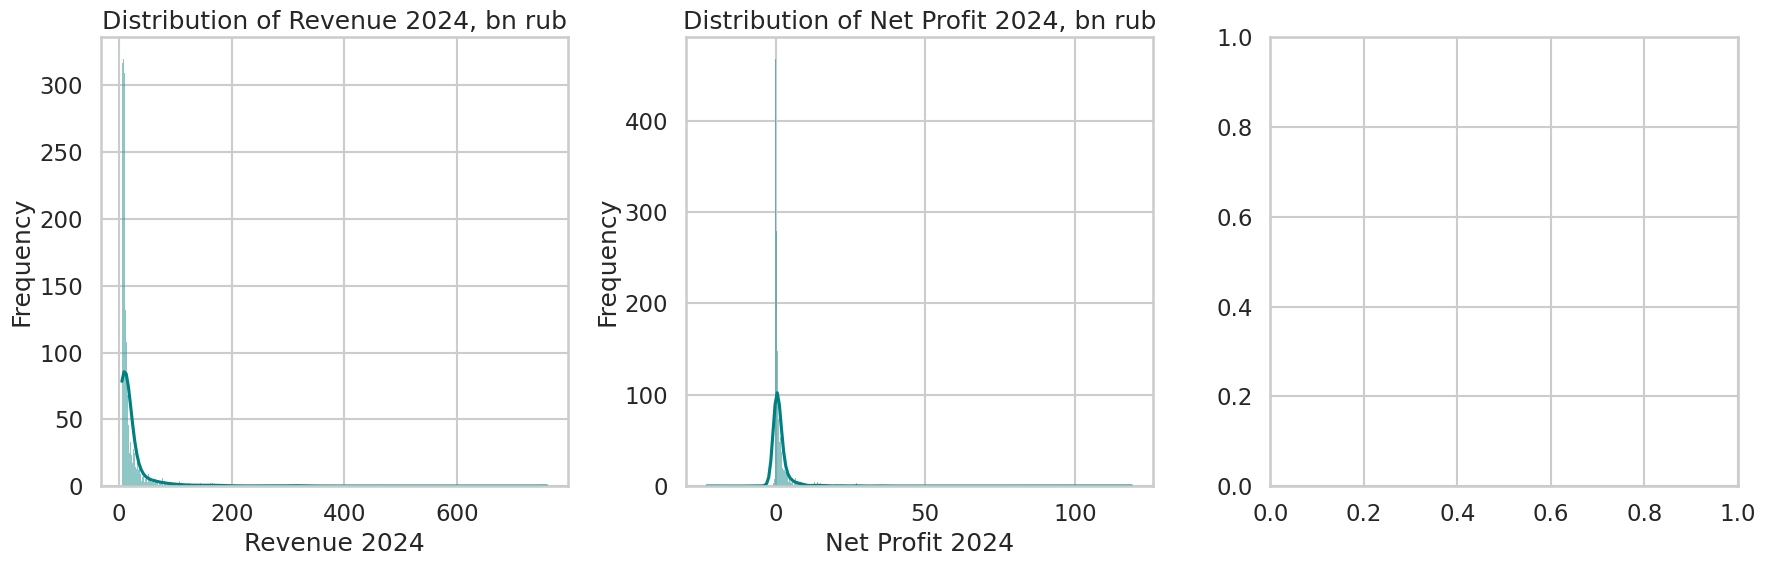

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the variables to plot
vars_to_plot = [
    ('rev2024', 'Revenue 2024'),
    ('np2024', 'Net Profit 2024')
]


# Set up the figure and axes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6)) # Changed nrows and ncols to fit 3 plots
axes = axes.flatten()

for i, (col, title) in enumerate(vars_to_plot):
    if col in df.columns:
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {title}, bn rub')
        axes[i].set_xlabel(title)
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_title(f'Column {col} not found')

plt.tight_layout()
plt.show()


In [ ]:
#Расчет переменных
# -----------------------------
df["Growth"] = (df["rev2024"] - df["rev2023"]) / df["rev2023"]
df["ProfitMargin"] = df["np2024"] / df["rev2024"]


In [ ]:
df

,id,company,date,age,rev2024,rev2023,rev2022,rev2021,rev2020,np2024,np2023,np2022,np2021,np2020,sector,Growth,ProfitMargin
0,1,"ООО ""ДНС Ритейл""",22 ноября 2010 г.,14,760.000000,727.0,597,562,428,15.00000,42.000,38,25,32,Retail (Special Lines),0.045392,0.019737
1,2,"АО ""Чери Автомобили Рус""",5 декабря 2005 г.,19,556.216781,147.0,62,16,4.8,2.80000,30.000,1.9,-0.83,-0.23,Retail (Automotive),2.783788,0.005034
2,3,"ООО ""АТИ""",20 февраля 2014 г.,10,683.000000,518.0,289,98,21,2.10000,1.100,-0.03,0.21,0.021,Transportation,0.318533,0.003075
3,4,"ООО ""Ле Монлид""",18 июня 2003 г.,21,456.631733,347.0,311,276,227,23.00000,5.000,9,4.1,5.1,Retail (Special Lines),0.315942,0.050369
4,5,"АО ""Апатит""",4 июля 1996 г.,28,361.641400,214.0,216,203,104,0.00000,28.000,40,32,21,Chemical (Basic),0.689913,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2281,2284,"ООО ""ПАРУС ЭЛЕКТРО""",1 марта 2011 г,13,6.400000,5.0,2.4,1.4,1.9,1.30000,0.708,0.48,0.052,0.068,Electrical Equipment,0.280000,0.203125
2282,2285,"ООО ""УМК""",19 ноября 2009 г,15,5.800000,5.0,3.9,4.1,3.2,0.49800,0.453,0.23,0.237,0.058,Food Processing,0.160000,0.085862
2283,2286,"ООО ""ЭЛАНКО РУС""",13 декабря 2013 г,11,5.003502,5.0,3.5,3.7,2.5,0.74500,0.660,0.72,0.49,-0.32,Drugs (Pharmaceutical),0.000700,0.148896
2284,2287,"ООО ""КОК РОШ ФАРМ""",25 сентября 2017 г,7,5.000820,5.0,1.9,6.5,0,0.45509,0.230,0.069,0.28,-71,Drugs (Pharmaceutical),0.000164,0.091003


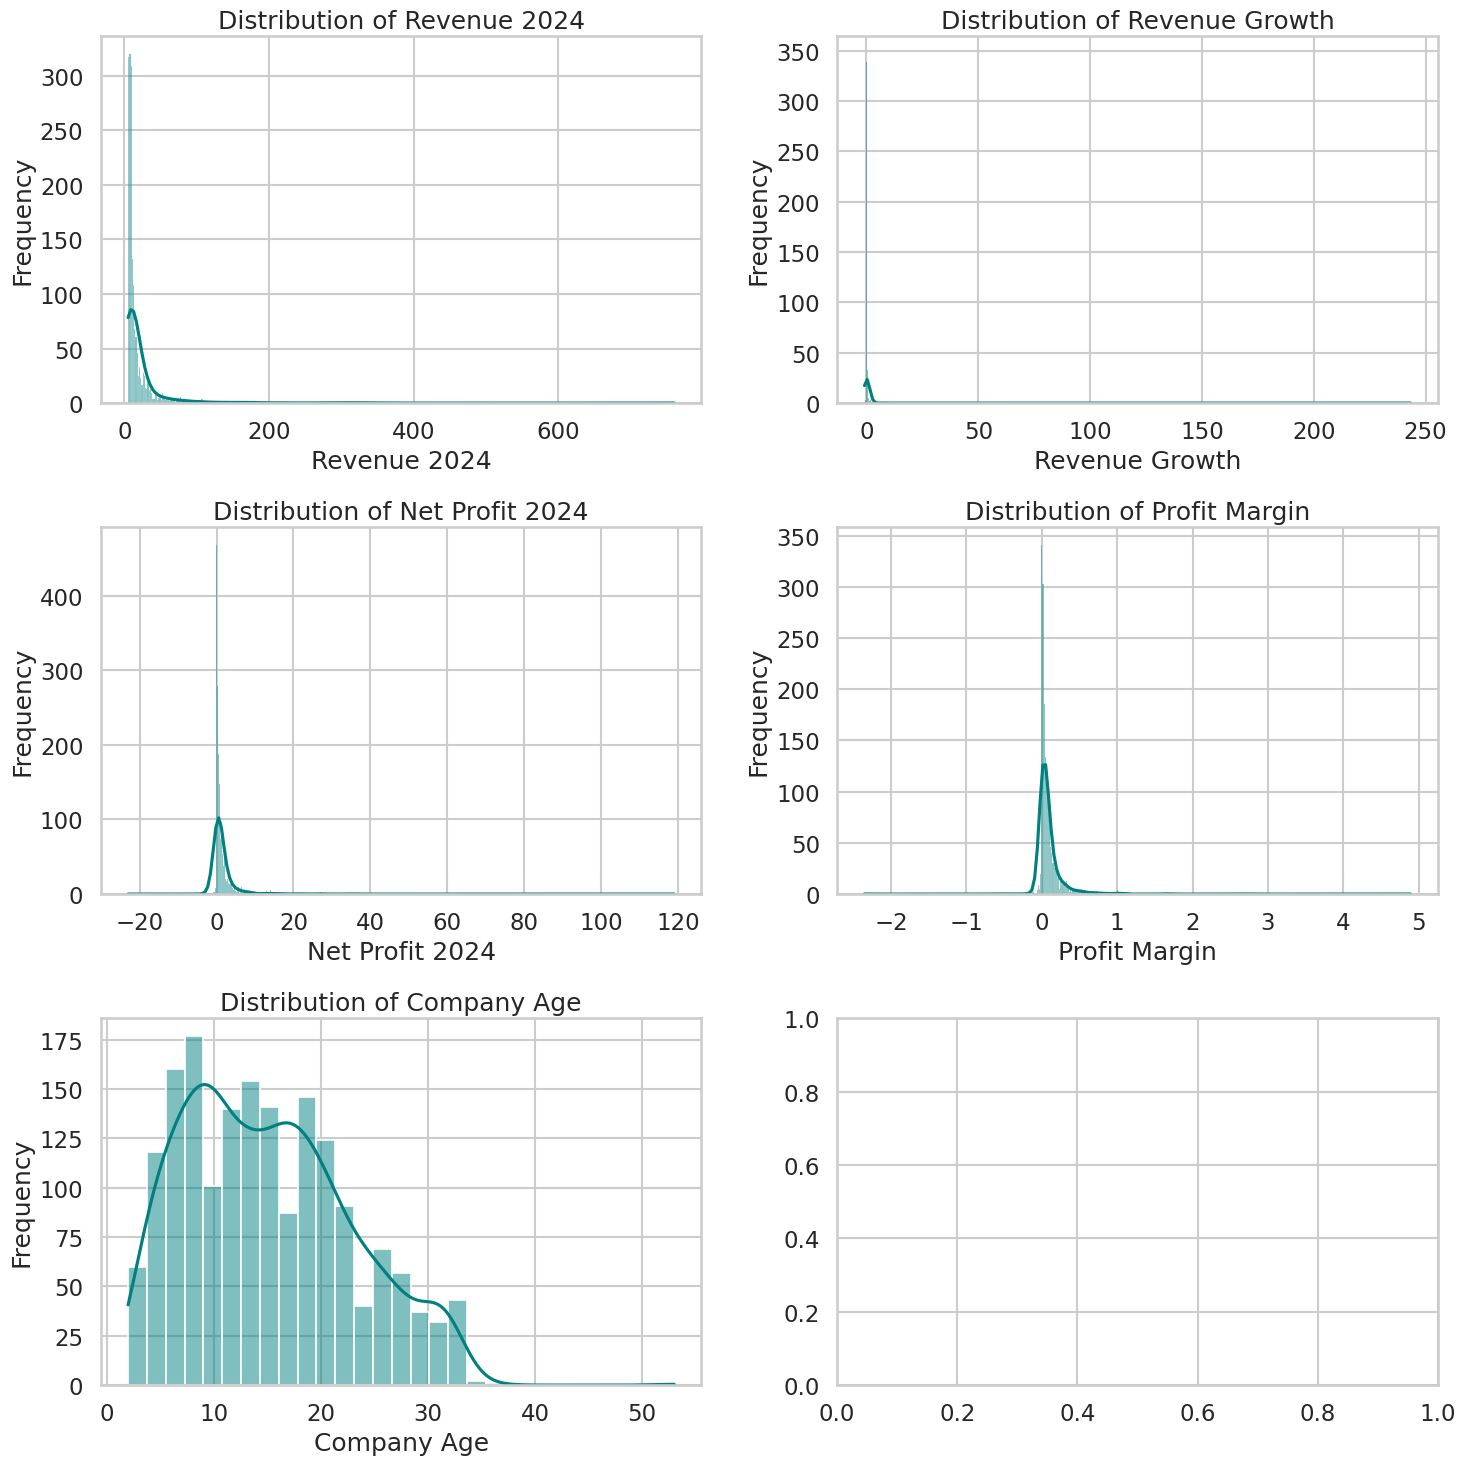

2. Кол-во: 1781


In [ ]:
# Визуализация с подсчётами
import matplotlib.pyplot as plt
import seaborn as sns

# Define the variables to plot
vars_to_plot = [
    ('rev2024', 'Revenue 2024'),
    ('Growth', 'Revenue Growth'),
    ('np2024', 'Net Profit 2024'),
    ('ProfitMargin', 'Profit Margin'),
    ('age', 'Company Age')
]

# Set up the figure and axes
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, (col, title) in enumerate(vars_to_plot):
    if col in df.columns:
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {title}')
        axes[i].set_xlabel(title)
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_title(f'Column {col} not found')

plt.tight_layout()
plt.show()

count_afterfilter = len(df)
print(f"2. Кол-во: {count_afterfilter}")

--- Applying Yeo-Johnson Transformation ---
Yeo-Johnson transformation applied to 12 numerical columns.
DataFrame shape after transformation and NaN handling: (1781, 29)
Optimal lambda values per column:
  rev2024: -0.9242
  rev2023: -0.6069
  rev2022: -0.4837
  rev2021: -0.2327
  rev2020: -0.2538
  np2024: 0.6322
  np2023: 0.6124
  np2022: 0.8764
  np2021: 1.1428
  np2020: 1.0858
  Growth: -0.8297
  ProfitMargin: 0.2672


/tmp/ipykernel_182/2868865641.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_182/2868865641.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

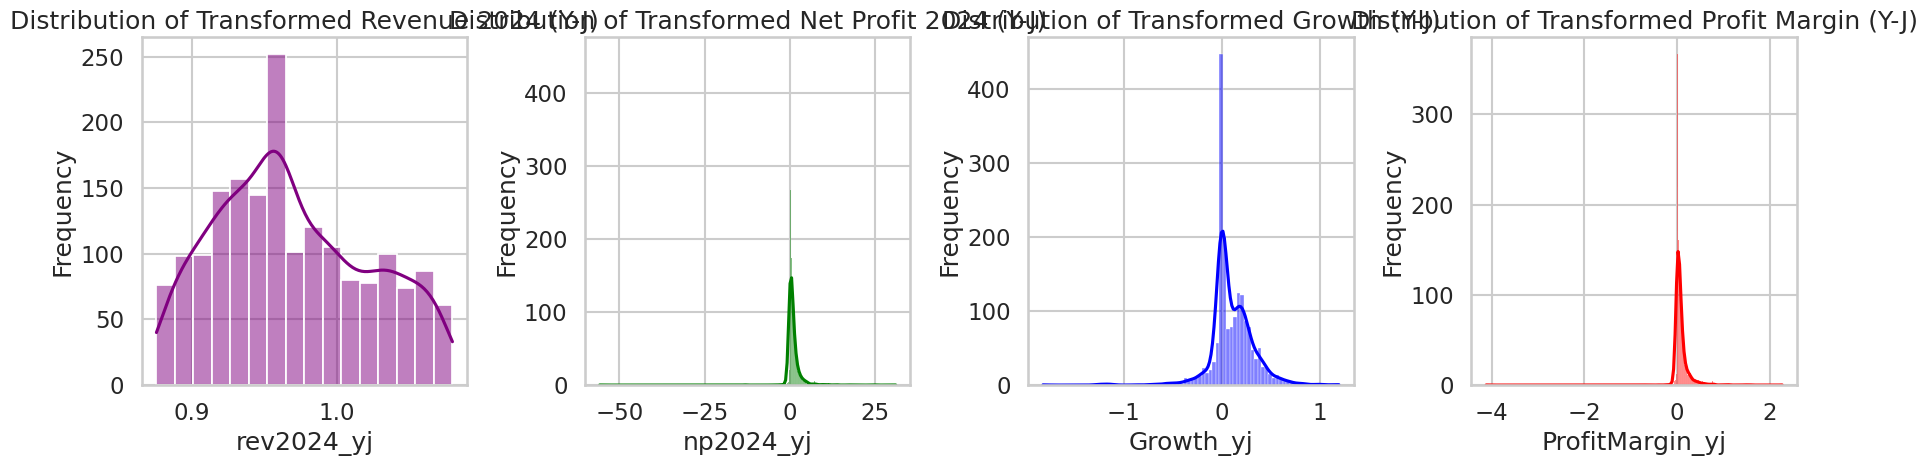

In [ ]:
import numpy as np
import scipy.stats as stats # Import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

print("--- Applying Yeo-Johnson Transformation ---")

# Ensure all rev and np columns are numeric, coercing errors
rev_np_columns = [col for col in df.columns if col.startswith('rev') or col.startswith('np')]
df[rev_np_columns] = df[rev_np_columns].apply(pd.to_numeric, errors='coerce')

# Columns to apply Yeo-Johnson transformation
columns_to_yj = [
    'rev2024', 'rev2023', 'rev2022', 'rev2021', 'rev2020',
    'np2024', 'np2023', 'np2022', 'np2021', 'np2020',
    'Growth', 'ProfitMargin' # Added Growth and ProfitMargin here
]

yj_lambdas = {} # Dictionary to store lambda values

# Apply Yeo-Johnson transformation to these columns and create new '_yj' columns
for col in columns_to_yj:
    # Ensure current column is numeric and replace inf/-inf with NaN
    df[col] = pd.to_numeric(df[col], errors='coerce') # Re-coerce in case previous operations introduced non-numeric

    # Identify and print problematic rows if non-finite values (other than NaN) exist
    valid_data_for_check = df[col].dropna()
    if not np.all(np.isfinite(valid_data_for_check)):
        print(f"Warning: Column '{col}' contains non-finite values (inf or -inf) after dropping NaNs.")
        non_finite_rows = df[~np.isfinite(df[col]) & df[col].notna()]
        if not non_finite_rows.empty:
            print(f"Problematic rows for '{col}':")
            display(non_finite_rows) # Show entire problematic rows

    df[col].replace([np.inf, -np.inf], np.nan, inplace=True)

    valid_data = df[col].dropna() # Now drop NaNs (including any newly created from inf/-inf replacement)

    if not valid_data.empty:
        try:
            transformed_data, yj_lambda = stats.yeojohnson(valid_data)
            df[f'{col}_yj'] = pd.Series(transformed_data, index=valid_data.index)
            yj_lambdas[col] = yj_lambda
        except ValueError as e:
            print(f"Error transforming column '{col}' even after handling: {e}")
            df[f'{col}_yj'] = np.nan
            yj_lambdas[col] = np.nan
    else:
        df[f'{col}_yj'] = np.nan # If column was all NaN, new column is all NaN
        yj_lambdas[col] = np.nan # No lambda if no data


print(f"Yeo-Johnson transformation applied to {len(columns_to_yj)} numerical columns.")
print(f"DataFrame shape after transformation and NaN handling: {df.shape}")
print("Optimal lambda values per column:")
for col, lmbda in yj_lambdas.items():
    print(f"  {col}: {lmbda:.4f}")

# --- Quick Visualization of Transformed Data ---
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
sns.histplot(df['rev2024_yj'], kde=True, color='purple')
plt.title('Distribution of Transformed Revenue 2024 (Y-J)')
plt.xlabel('rev2024_yj')
plt.ylabel('Frequency')

plt.subplot(1, 4, 2)
sns.histplot(df['np2024_yj'], kde=True, color='green')
plt.title('Distribution of Transformed Net Profit 2024 (Y-J)')
plt.xlabel('np2024_yj')
plt.ylabel('Frequency')

plt.subplot(1, 4, 3)
sns.histplot(df['Growth_yj'], kde=True, color='blue')
plt.title('Distribution of Transformed Growth (Y-J)')
plt.xlabel('Growth_yj')
plt.ylabel('Frequency')

plt.subplot(1, 4, 4)
sns.histplot(df['ProfitMargin_yj'], kde=True, color='red')
plt.title('Distribution of Transformed Profit Margin (Y-J)')
plt.xlabel('ProfitMargin_yj')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
df

,id,company,date,age,rev2024,rev2023,rev2022,rev2021,rev2020,np2024,...,rev2022_yj,rev2021_yj,rev2020_yj,np2024_yj,np2023_yj,np2022_yj,np2021_yj,np2020_yj,Growth_yj,ProfitMargin_yj
0,1,"ООО ""ДНС Ритейл""",22 ноября 2010 г.,14,760.000000,727.0,597.0,562.0,428.0,15.00000,...,1.973707,3.312871,3.093887,7.546221,14.710173,27.156446,35.353485,40.103644,0.043584,0.019596
1,2,"АО ""Чери Автомобили Рус""",5 декабря 2005 г.,19,556.216781,147.0,62.0,16.0,4.8,2.80000,...,1.788833,2.074649,1.418050,2.096804,11.742389,1.759978,-0.791766,-0.227900,0.805721,0.005025
2,3,"ООО ""АТИ""",20 февраля 2014 г.,10,683.000000,518.0,289.0,98.0,21.0,2.10000,...,1.934369,2.822197,2.141987,1.652528,0.939217,-0.030055,0.212976,0.021019,0.247093,0.003071
3,4,"ООО ""Ле Монлид""",18 июня 2003 г.,21,456.631733,347.0,311.0,276.0,227.0,23.00000,...,1.938998,3.136246,2.946685,10.213197,3.259401,7.443540,4.756624,5.639841,0.245528,0.049465
4,5,"АО ""Апатит""",4 июля 1996 г.,28,361.641400,214.0,216.0,203.0,104.0,0.00000,...,1.914314,3.050597,2.730687,0.000000,11.207098,28.424333,46.699635,25.493735,0.425393,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2281,2284,"ООО ""ПАРУС ЭЛЕКТРО""",1 марта 2011 г,13,6.400000,5.0,2.4,1.4,1.9,1.30000,...,0.923624,0.792047,0.932971,1.096330,0.633506,0.467820,0.052190,0.068194,0.223221,0.189566
2282,2285,"ООО ""УМК""",19 ноября 2009 г,15,5.800000,5.0,3.9,4.1,3.2,0.49800,...,1.108963,1.355975,1.202756,0.460447,0.419834,0.226983,0.240765,0.058142,0.139646,0.083287
2283,2286,"ООО ""ЭЛАНКО РУС""",13 декабря 2013 г,11,5.003502,5.0,3.5,3.7,2.5,0.74500,...,1.068656,1.299537,1.073119,0.667317,0.594285,0.694309,0.505171,-0.316045,0.000700,0.141407
2284,2287,"ООО ""КОК РОШ ФАРМ""",25 сентября 2017 г,7,5.000820,5.0,1.9,6.5,0.0,0.45509,...,0.832143,1.608440,0.000000,0.423267,0.220710,0.068713,0.285200,-53.474648,0.000164,0.088119


In [ ]:
import pandas as pd

# List of original columns to drop
columns_to_drop = [
    'rev2024', 'rev2023', 'rev2022', 'rev2021', 'rev2020',
    'np2024', 'np2023', 'np2022', 'np2021', 'np2020',
    'Growth', 'ProfitMargin'
]

# Drop the columns if they exist in the DataFrame
df.drop(columns=columns_to_drop, errors='ignore', inplace=True)

print(f"Original (untransformed) columns removed: {columns_to_drop}")
print(f"DataFrame shape after removing original columns: {df.shape}")

Original (untransformed) columns removed: ['rev2024', 'rev2023', 'rev2022', 'rev2021', 'rev2020', 'np2024', 'np2023', 'np2022', 'np2021', 'np2020', 'Growth', 'ProfitMargin']
DataFrame shape after removing original columns: (1781, 17)


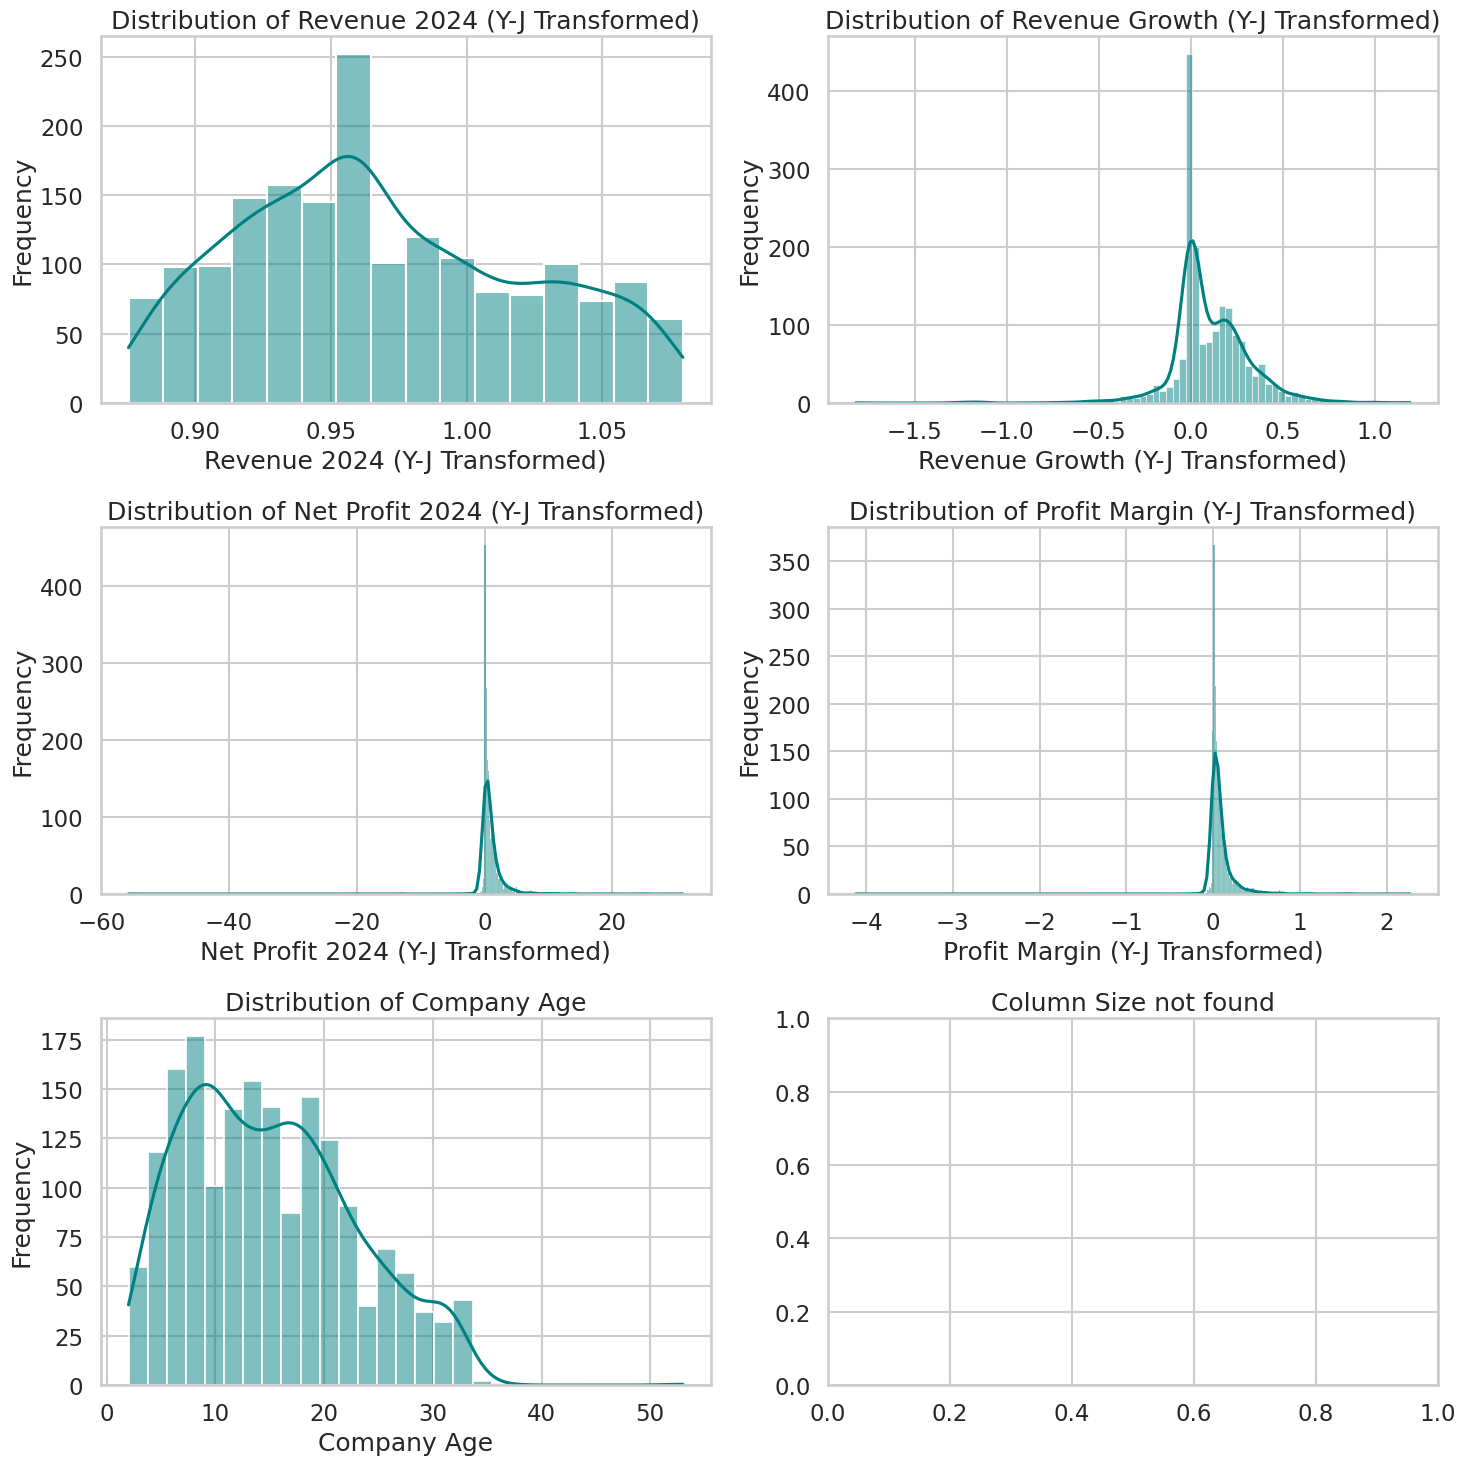

In [ ]:
# Визуализация после трансформации
vars_to_plot = [
    ('rev2024_yj', 'Revenue 2024 (Y-J Transformed)'),
    ('Growth_yj', 'Revenue Growth (Y-J Transformed)'),
    ('np2024_yj', 'Net Profit 2024 (Y-J Transformed)'),
    ('ProfitMargin_yj', 'Profit Margin (Y-J Transformed)'),
    ('age', 'Company Age'),
    ('Size', 'Company Size (from YJ Revenue)')
]

# Set up the figure and axes
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, (col, title) in enumerate(vars_to_plot):
    if col in df.columns:
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {title}')
        axes[i].set_xlabel(title)
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_title(f'Column {col} not found')

plt.tight_layout()
plt.show()

In [ ]:
df

,id,company,date,age,sector,rev2024_yj,rev2023_yj,rev2022_yj,rev2021_yj,rev2020_yj,np2024_yj,np2023_yj,np2022_yj,np2021_yj,np2020_yj,Growth_yj,ProfitMargin_yj
0,1,"ООО ""ДНС Ритейл""",22 ноября 2010 г.,14,Retail (Special Lines),1.079684,1.617435,1.973707,3.312871,3.093887,7.546221,14.710173,27.156446,35.353485,40.103644,0.043584,0.019596
1,2,"АО ""Чери Автомобили Рус""",5 декабря 2005 г.,19,Retail (Automotive),1.078899,1.568248,1.788833,2.074649,1.418050,2.096804,11.742389,1.759978,-0.791766,-0.227900,0.805721,0.005025
2,3,"ООО ""АТИ""",20 февраля 2014 г.,10,Transportation,1.079440,1.610554,1.934369,2.822197,2.141987,1.652528,0.939217,-0.030055,0.212976,0.021019,0.247093,0.003071
3,4,"ООО ""Ле Монлид""",18 июня 2003 г.,21,Retail (Special Lines),1.078273,1.600379,1.938998,3.136246,2.946685,10.213197,3.259401,7.443540,4.756624,5.639841,0.245528,0.049465
4,5,"АО ""Апатит""",4 июля 1996 г.,28,Chemical (Basic),1.077371,1.584343,1.914314,3.050597,2.730687,0.000000,11.207098,28.424333,46.699635,25.493735,0.425393,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2281,2284,"ООО ""ПАРУС ЭЛЕКТРО""",1 марта 2011 г,13,Electrical Equipment,0.911854,1.092266,0.923624,0.792047,0.932971,1.096330,0.633506,0.467820,0.052190,0.068194,0.223221,0.189566
2282,2285,"ООО ""УМК""",19 ноября 2009 г,15,Food Processing,0.898022,1.092266,1.108963,1.355975,1.202756,0.460447,0.419834,0.226983,0.240765,0.058142,0.139646,0.083287
2283,2286,"ООО ""ЭЛАНКО РУС""",13 декабря 2013 г,11,Drugs (Pharmaceutical),0.875568,1.092266,1.068656,1.299537,1.073119,0.667317,0.594285,0.694309,0.505171,-0.316045,0.000700,0.141407
2284,2287,"ООО ""КОК РОШ ФАРМ""",25 сентября 2017 г,7,Drugs (Pharmaceutical),0.875482,1.092266,0.832143,1.608440,0.000000,0.423267,0.220710,0.068713,0.285200,-53.474648,0.000164,0.088119


In [ ]:
# -----------------------------
# 4. Фильтрация выбросов (MAD) и по Revenue
# -----------------------------

# Calculate MAD for the specified columns
for col in ['rev2024_yj', 'Growth_yj', 'np2024_yj', 'ProfitMargin_yj']:
    median_val = df[col].median()
    mad_val = np.median(np.abs(df[col] - median_val))

    # Define outlier bounds (e.g., 3 MADs from the median)
    if mad_val > 0:
        lower_bound = median_val - 3 * mad_val
        upper_bound = median_val + 3 * mad_val
        # Filter out outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


final_count = len(df)
print(f"3. Кол-во компаний после фильтрации выбросов (MAD): {final_count}")
print(f"----------------------------")

3. Кол-во компаний после фильтрации выбросов (MAD): 1060
----------------------------


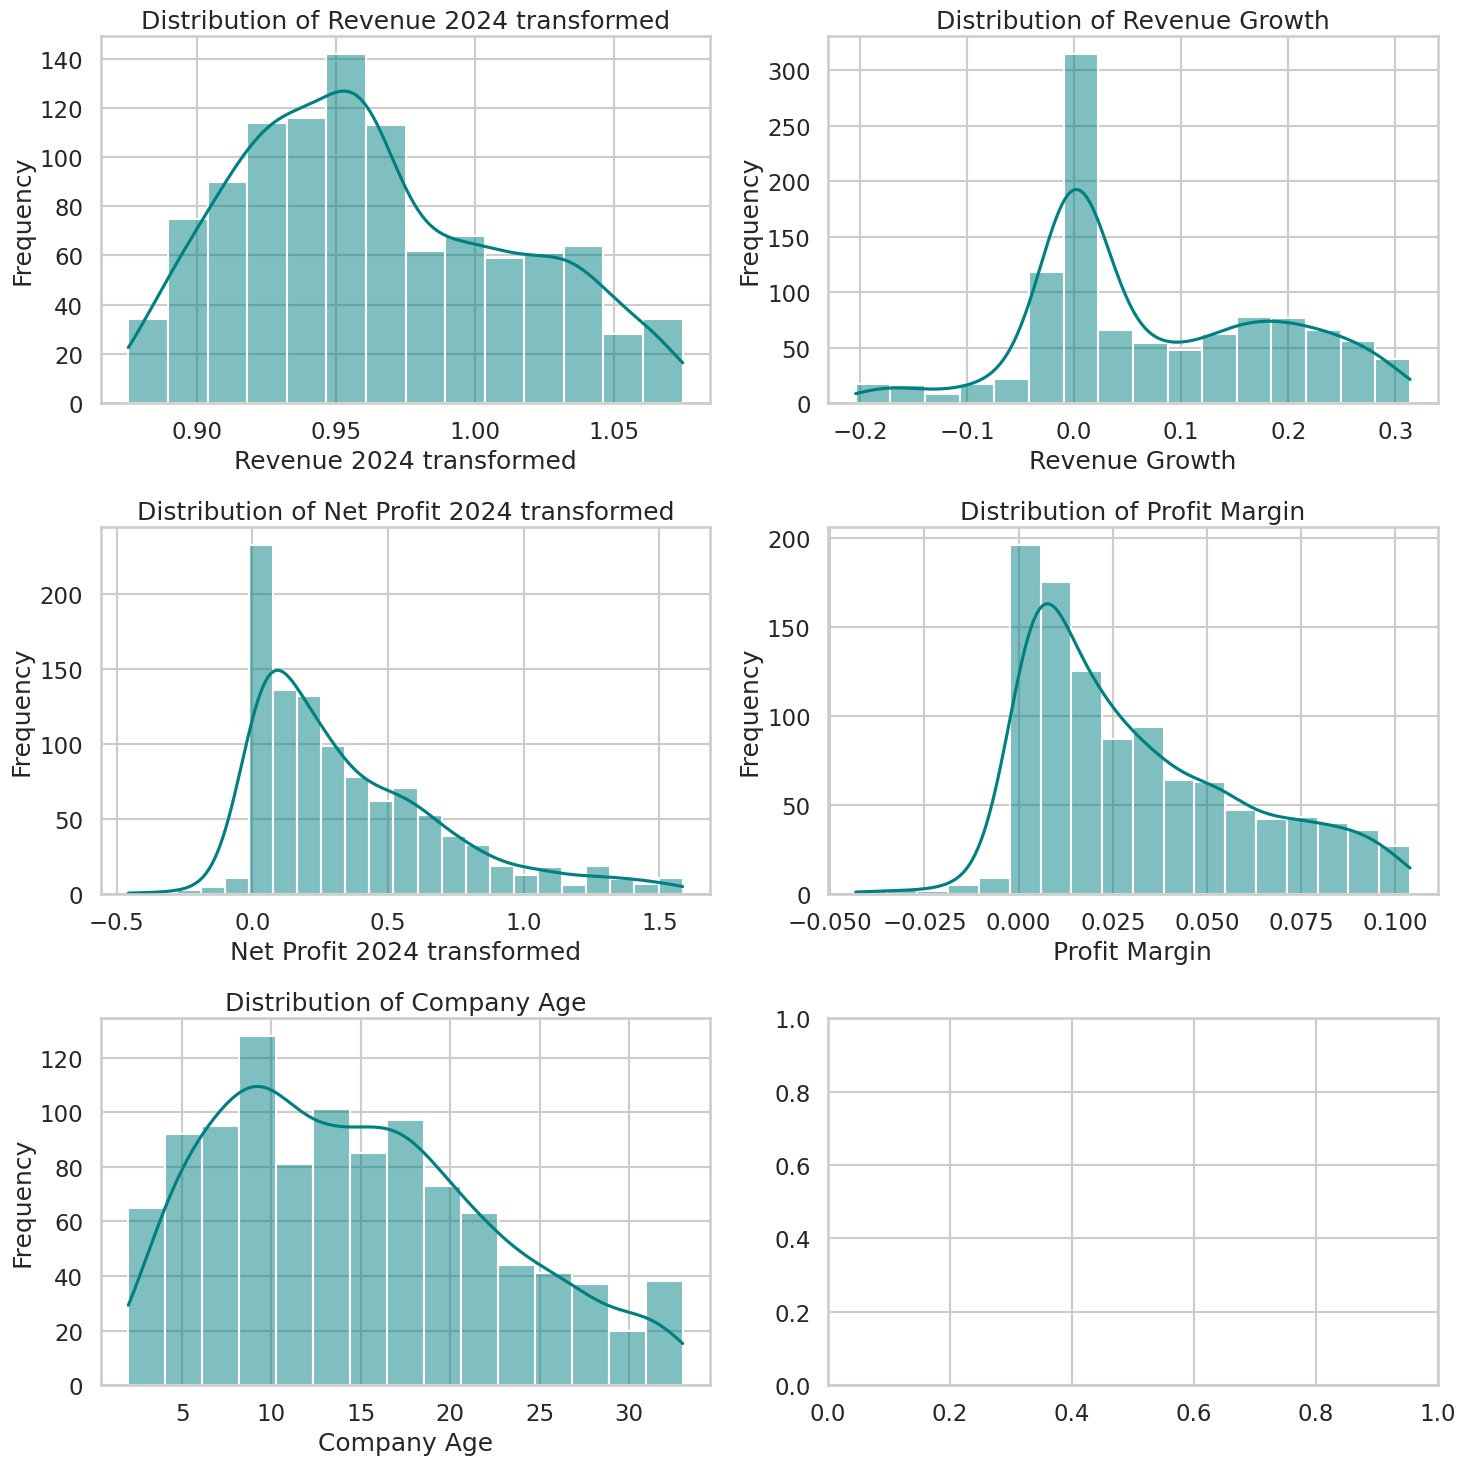

In [ ]:
# Визуализация после фильтрации выбросов
vars_to_plot = [
    ('rev2024_yj', 'Revenue 2024 transformed'),
    ('Growth_yj', 'Revenue Growth'),
    ('np2024_yj', 'Net Profit 2024 transformed'),
    ('ProfitMargin_yj', 'Profit Margin'),
    ('age', 'Company Age')
]

# Set up the figure and axes
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, (col, title) in enumerate(vars_to_plot):
    if col in df.columns:
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {title}')
        axes[i].set_xlabel(title)
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_title(f'Column {col} not found')

plt.tight_layout()
plt.show()

In [ ]:
df

,id,company,date,age,sector,rev2024_yj,rev2023_yj,rev2022_yj,rev2021_yj,rev2020_yj,np2024_yj,np2023_yj,np2022_yj,np2021_yj,np2020_yj,Growth_yj,ProfitMargin_yj
16,17,"АО ""Рольф""",27 июля 2021 г.,3,Retail (Automotive),1.074601,1.587823,1.891042,3.110410,NaN,0.311602,3.108106,7.893331,-3.941615,NaN,-0.077223,0.001508
34,35,"АО ""КТК-Р""",6 февраля 1997 г.,27,Oil/Gas Distribution,1.072485,1.569832,1.860952,2.910305,2.775872,0.488775,20.776749,28.424333,100.543582,76.174963,0.084964,0.003195
36,37,"ООО ""ОСК 1520""",7 ноября 2007 г.,17,Engineering/Construction,1.070567,1.568248,1.817732,2.506312,2.440590,1.157223,8.904060,9.662911,3.148452,3.340974,-0.080058,0.010133
38,39,"ООО ""ФК Гранд Капитал""",9 сентября 2002 г.,22,Household Products,1.072431,1.566229,1.859222,2.829046,2.671578,0.031814,0.425885,0.750300,0.357990,0.426756,0.147368,0.000194
43,44,"ООО ""Компания Сим-Авто""",21 ноября 2007 г.,17,Retail (Automotive),1.069911,1.562930,1.811374,2.652498,2.374853,0.590527,6.222370,4.664591,3.513455,1.033845,-0.031150,0.005082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258,2261,"ООО ""КЕЙ ТИ ЭН ДЖИ РУС""",4 июня 2008 г,16,Tobacco,0.923685,1.097809,1.034761,1.184902,1.132336,0.516030,0.159148,-215.722724,0.068324,0.123626,0.278487,0.078163
2268,2271,"АО ""КИЗЛЯРСКИЙ КОНЬЯЧНЫЙ ЗАВОД""",9 февраля 2018 г,6,Beverage (Alcoholic),0.913952,1.092266,1.118284,1.147530,1.007168,0.522812,0.684342,0.551357,0.437631,0.494905,0.235773,0.085154
2274,2277,"ООО ""АВЕТА""",12 августа 2008 г,16,Drugs (Pharmaceutical),0.887418,1.092266,1.118284,1.299537,1.265231,0.011974,0.001200,0.008795,0.008205,0.030038,0.074555,0.002220
2282,2285,"ООО ""УМК""",19 ноября 2009 г,15,Food Processing,0.898022,1.092266,1.108963,1.355975,1.202756,0.460447,0.419834,0.226983,0.240765,0.058142,0.139646,0.083287


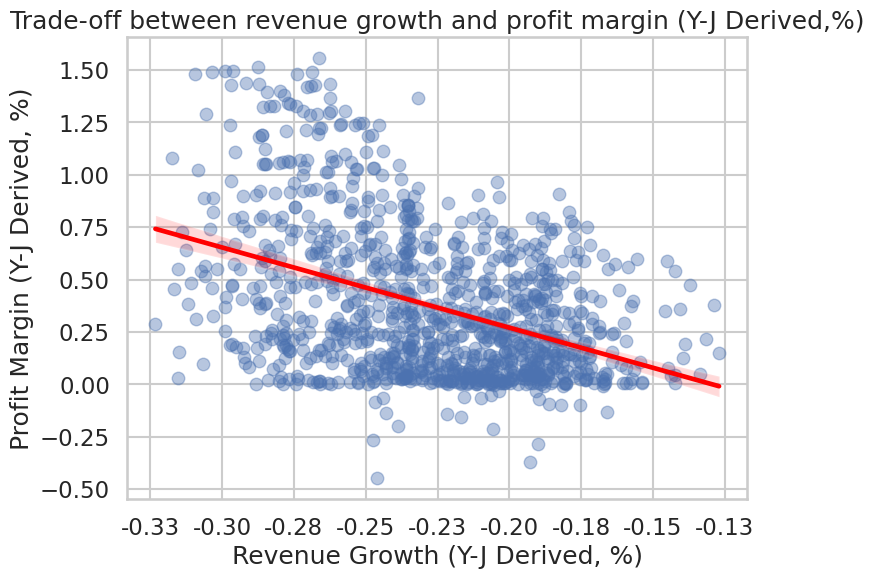

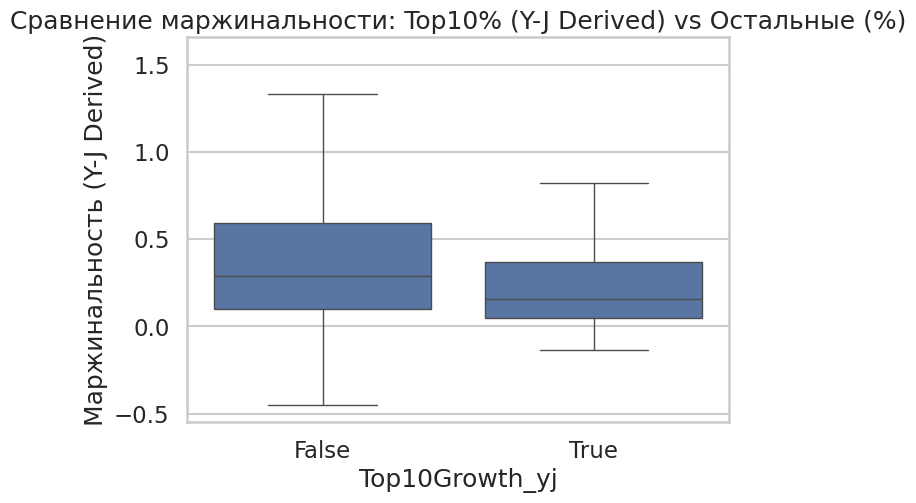

In [ ]:
# -----------------------------
# 8. Визуализация (с YJ данными)
# -----------------------------
import matplotlib.ticker as ticker

df_plot = df.copy()

# Calculate Growth and ProfitMargin using Yeo-Johnson transformed data
# Ensure to handle potential NaNs that might arise from division
df_plot["Growth_yj"] = (df_plot["rev2024_yj"] - df_plot["rev2023_yj"]) / df_plot["rev2023_yj"]
df_plot["ProfitMargin_yj"] = df_plot["np2024_yj"] / df_plot["rev2024_yj"]


# Recalculate Top10Growth based on YJ-derived Growth
df_plot["Top10Growth_yj"] = df_plot["Growth_yj"] >= df_plot["Growth_yj"].quantile(0.9)


# H1: Trade-off with YJ-derived data
plt.figure(figsize=(8,6))
sns.regplot(data=df_plot, x="Growth_yj", y="ProfitMargin_yj", scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title("Trade-off between revenue growth and profit margin (Y-J Derived,%)")
plt.xlabel("Revenue Growth (Y-J Derived, %)")
plt.ylabel("Profit Margin (Y-J Derived, %)")
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f')) # Apply formatting
plt.show()

# Top10% Boxplot with YJ-derived data
plt.figure(figsize=(7,5))
sns.boxplot(data=df_plot, x="Top10Growth_yj", y="ProfitMargin_yj", fliersize=0)
plt.title("Сравнение маржинальности: Top10% (Y-J Derived) vs Остальные (%)")
plt.ylabel("Маржинальность (Y-J Derived)")
plt.show()

выводим таблицу

In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Recalculate 'Size' column as it was commented out from K5vmeEE3Q3vc
df["Size"] = df["rev2024_yj"]


# Drop any NaNs that might have been created by these new calculations
df.dropna(subset=["Growth_yj", "ProfitMargin_yj", "Size", "age"], inplace=True)

# OLS regression (Baseline linear model) using YJ-derived data
X_linear = sm.add_constant(df[['Growth_yj', 'Size', 'age']])
ols_model = sm.OLS(df['ProfitMargin_yj'], X_linear).fit()
print("--- OLS Linear Regression (Y-J Derved Data) ---")
print(ols_model.summary().tables[1])
print("\n--- Overall Model Fit ---")
print(f"R-squared: {ols_model.rsquared:.4f}")
print(f"Adj. R-squared: {ols_model.rsquared_adj:.4f}")
print(f"F-statistic: {ols_model.fvalue:.2f}, Prob (F-statistic): {ols_model.f_pvalue:.4f}")

--- OLS Linear Regression (Y-J Derved Data) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0658      0.018      3.658      0.000       0.030       0.101
Growth_yj     -0.0037      0.008     -0.474      0.636      -0.019       0.012
Size          -0.0408      0.019     -2.180      0.030      -0.077      -0.004
age            0.0004      0.000      3.133      0.002       0.000       0.001

--- Overall Model Fit ---
R-squared: 0.0123
Adj. R-squared: 0.0095
F-statistic: 4.39, Prob (F-statistic): 0.0045


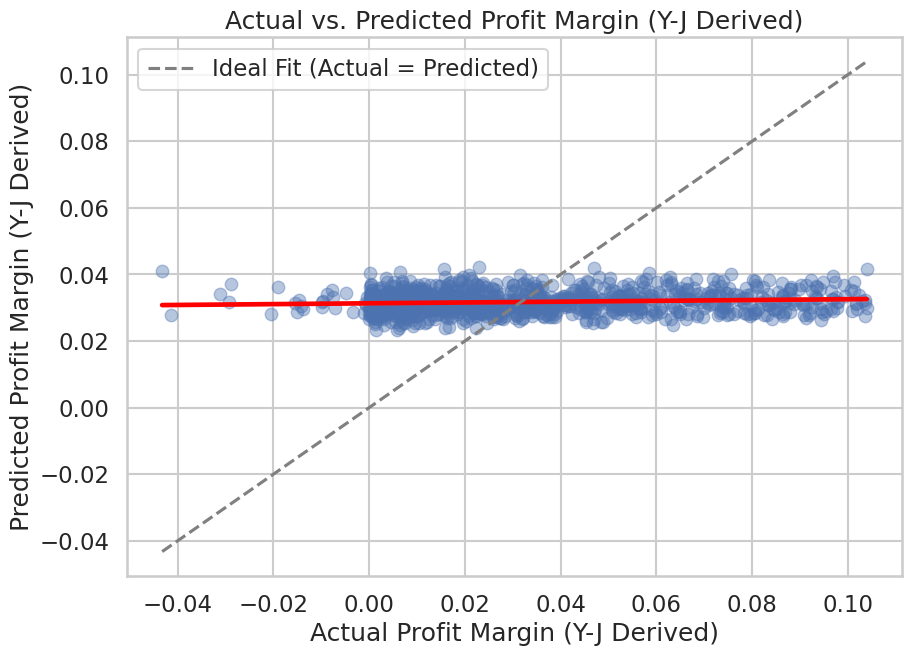

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming ols_model and df are available from the previous cell (m8_VfhQBqe3_)
# Get predicted values from the OLS model
predicted_values = ols_model.predict(X_linear)

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.regplot(x=df['ProfitMargin_yj'], y=predicted_values, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.plot([df['ProfitMargin_yj'].min(), df['ProfitMargin_yj'].max()],
         [df['ProfitMargin_yj'].min(), df['ProfitMargin_yj'].max()],
         '--', color='gray', label='Ideal Fit (Actual = Predicted)')

plt.title('Actual vs. Predicted Profit Margin (Y-J Derived)')
plt.xlabel('Actual Profit Margin (Y-J Derived)')
plt.ylabel('Predicted Profit Margin (Y-J Derived)')
plt.legend()
plt.grid(True)
plt.show()


--- Analysis with Yeo-Johnson Transformed Features ---


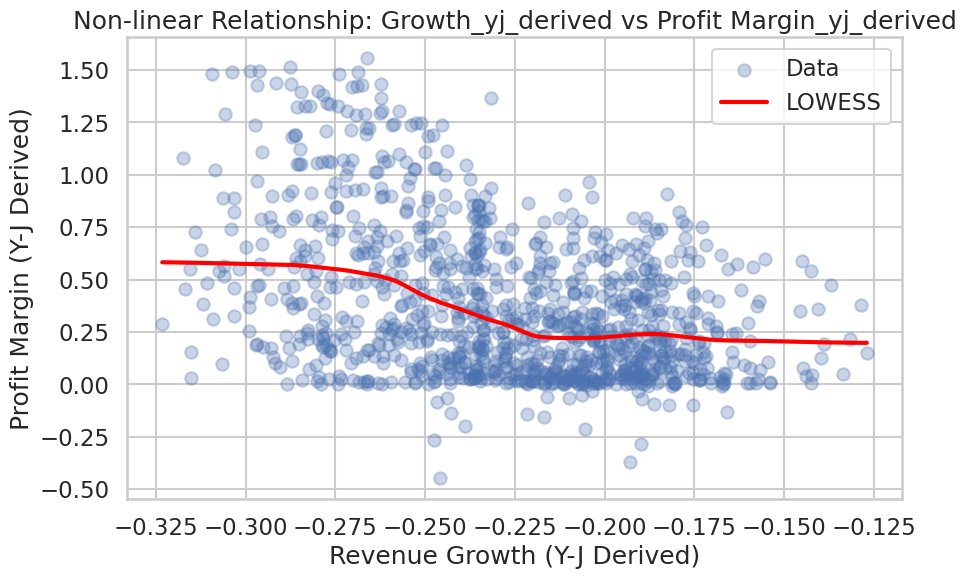


--- Quadratic Regression (Y-J Derived Data, Testing for U-shape) ---
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.6626      0.306      2.167      0.030       0.063       1.262
Growth_yj_derived        6.5562      2.702      2.427      0.015       1.255      11.857
Growth_yj_derived_sq    22.6299      5.860      3.862      0.000      11.132      34.128

--- Overall Quadratic Model Fit ---
R-squared: 0.1815
Adj. R-squared: 0.1799
F-statistic: 117.16, Prob (F-statistic): 0.0000


In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Ensure these YJ-derived columns are available for this cell
df["Size"] = df["rev2024_yj"]
df["Growth_yj_derived"] = (df["rev2024_yj"] - df["rev2023_yj"]) / df["rev2023_yj"]
df["ProfitMargin_yj_derived"] = df["np2024_yj"] / df["rev2024_yj"]
df.dropna(subset=["Growth_yj_derived", "ProfitMargin_yj_derived"], inplace=True)

print("--- Analysis with Yeo-Johnson Transformed Features ---")

# 1️⃣ Scatter + LOWESS (Hyperbola/Non-linear check) using YJ-derived data
lowess = sm.nonparametric.lowess(df["ProfitMargin_yj_derived"], df["Growth_yj_derived"], frac=0.3)

plt.figure(figsize=(10, 6))
plt.scatter(df["Growth_yj_derived"], df["ProfitMargin_yj_derived"], alpha=0.3, label='Data')
plt.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=3, label='LOWESS')
plt.title("Non-linear Relationship: Growth_yj_derived vs Profit Margin_yj_derived")
plt.xlabel("Revenue Growth (Y-J Derived)")
plt.ylabel("Profit Margin (Y-J Derived)")
plt.legend()
plt.show()

# 2️⃣ Quadratic regression (Test for hyperbola/parabola shape) using YJ-derived data
df['Growth_yj_derived_sq'] = df['Growth_yj_derived']**2
X_quad = sm.add_constant(df[['Growth_yj_derived', 'Growth_yj_derived_sq']])
quad_model = sm.OLS(df['ProfitMargin_yj_derived'], X_quad).fit()
print("\n--- Quadratic Regression (Y-J Derived Data, Testing for U-shape) ---")
print(quad_model.summary().tables[1])
print("\n--- Overall Quadratic Model Fit ---")
print(f"R-squared: {quad_model.rsquared:.4f}")
print(f"Adj. R-squared: {quad_model.rsquared_adj:.4f}")
print(f"F-statistic: {quad_model.fvalue:.2f}, Prob (F-statistic): {quad_model.f_pvalue:.4f}")


Q3 Companies: Show the strongest and only statistically significant negative relationship (Beta = -0.0497, p < 0.001). For these firms, higher growth is clearly associated with lower margins.
Q1 (Smallest): Actually show a slightly positive but non-significant trend, suggesting growth doesn't necessarily hurt margins for the smallest firms in this dataset.
Q4 (Largest): The relationship is negative but not statistically significant (p = 0.422), indicating a more stable or complex dynamic at the highest revenue level

теперь в разрезе отраслей. еще отсеются компании которые нив одну группу не попали

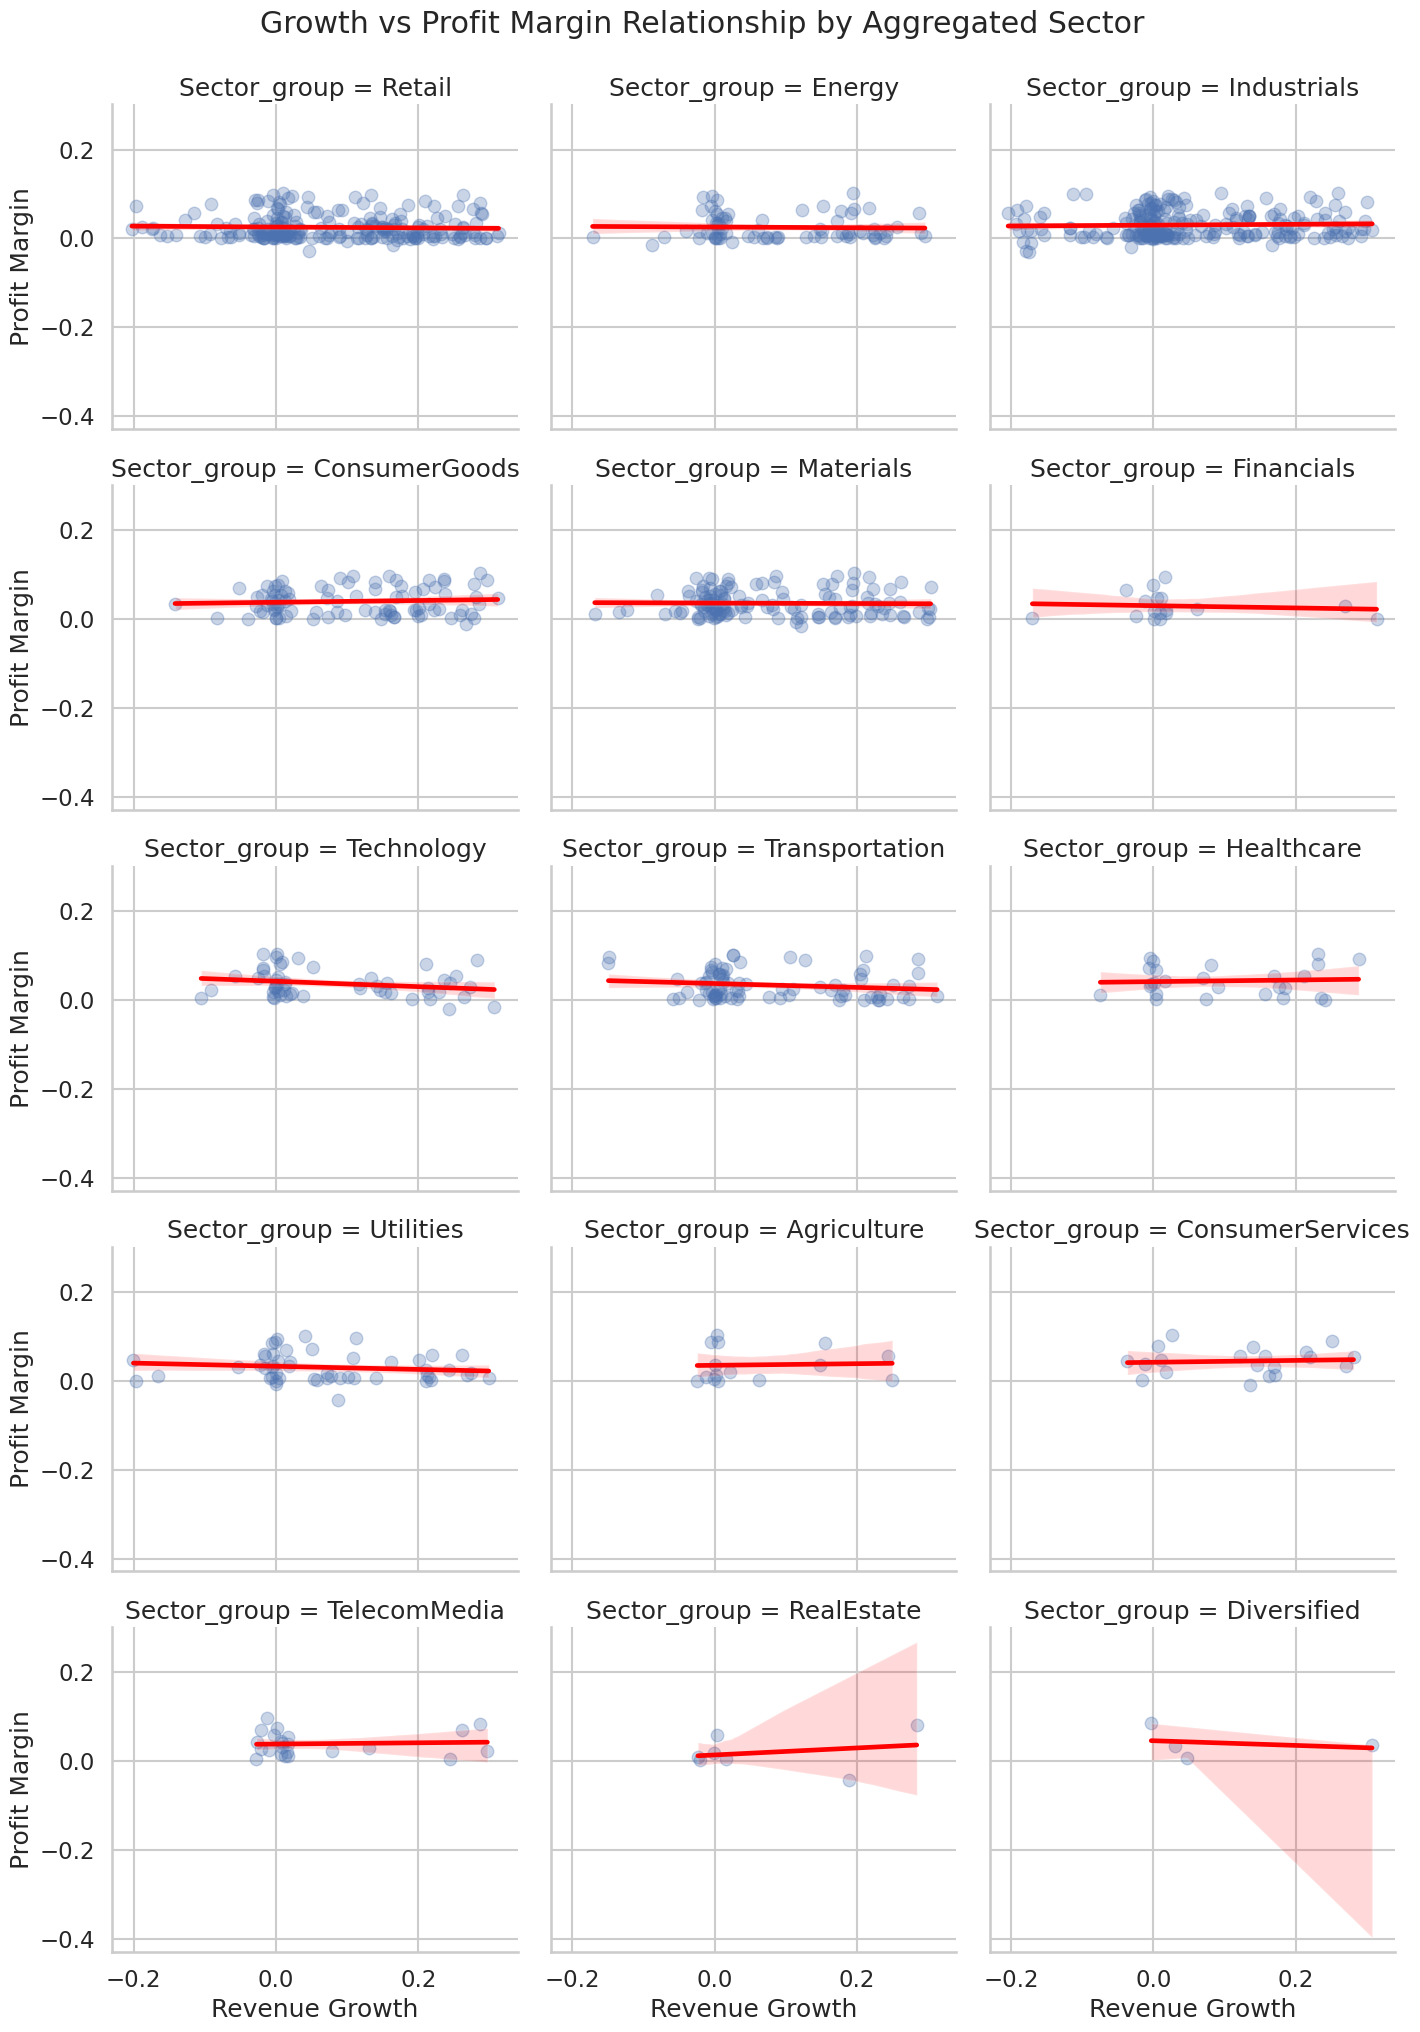

,Growth_yj,ProfitMargin_yj,Company_Count
Sector_group,,,
Agriculture,0.056793,0.035502,15
ConsumerGoods,0.107721,0.040163,92
ConsumerServices,0.122027,0.043840,20
Diversified,0.095441,0.041353,4
Energy,0.091236,0.024979,77
Financials,0.028923,0.029608,17
Healthcare,0.098672,0.042885,26
Industrials,0.049555,0.030391,236
Materials,0.079620,0.035836,132


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sector_map = {

# ENERGY (extraction and oil infrastructure)
"Oil/Gas Distribution":"Energy",
"Oil/Gas (Production and Exploration)":"Energy",
"Oil/Gas (Integrated)":"Energy",
"Oilfield Svcs/Equip.":"Energy",
"Coal & Related Energy":"Energy",

# MATERIALS (basic inputs to industry)
"Chemical (Basic)":"Materials",
"Chemical (Specialty)":"Materials",
"Chemical (Diversified)":"Materials",
"Steel":"Materials",
"Metals & Mining":"Materials",
"Precious Metals":"Materials",
"Paper/Forest Products":"Materials",
"Packaging & Container":"Materials",
"Rubber& Tires":"Materials",
"Building Materials":"Materials",
"Construction supplies":"Materials",

# INDUSTRIALS (manufacturing and capital goods)
"Machinery":"Industrials",
"Electrical Equipment":"Industrials",
"Engineering/Construction":"Industrials",
"Aerospace/Defense":"Industrials",
"Shipbuilding & Marine":"Industrials",
"Office Equipment & Services":"Industrials",
"Auto & Truck":"Industrials",
"Auto Parts":"Industrials",

# TRANSPORTATION (logistics and carriers)
"Transportation":"Transportation",
"Air Transport":"Transportation",
"Trucking":"Transportation",
"Transportation (Railroads)":"Transportation",

# TECHNOLOGY
"Computer Services":"Technology",
"Information Services":"Technology",
"Computers/Peripherals":"Technology",
"Software (System & Application)":"Technology",
"Electronics (General)":"Technology",
"Electronics (Consumer & Office)":"Technology",

# TELECOM AND MEDIA
"Telecom. Services":"TelecomMedia",
"Telecom (Wireless)":"TelecomMedia",
"Broadcasting":"TelecomMedia",
"Publishing & Newspapers":"TelecomMedia",
"Advertising":"TelecomMedia",

# HEALTHCARE
"Drugs (Biotechnology)":"Healthcare",
"Drugs (Pharmaceutical)":"Healthcare",
"Healthcare Products":"Healthcare",
"Hospitals/Healthcare Facilities":"Healthcare",

# FINANCIALS
"Bank (Money Center)":"Financials",
"Brokerage & Investment Banking":"Financials",
"Investments & Asset Management":"Financials",
"Financial Svcs. (Non-bank & Insurance)":"Financials",
"Insurance (General)":"Financials",

# CONSUMER GOODS (manufactured goods sold to consumers)
"Food Processing":"ConsumerGoods",
"Beverage (Soft)":"ConsumerGoods",
"Beverage (Alcoholic)":"ConsumerGoods",
"Tobacco":"ConsumerGoods",
"Apparel":"ConsumerGoods",
"Household Products":"ConsumerGoods",
"Furn/Home Furnishings":"ConsumerGoods",

# RETAIL / DISTRIBUTION
"Retail (General)":"Retail",
"Retail (Special Lines)":"Retail",
"Retail (Automotive)":"Retail",
"Retail (Distributors)":"Retail",
"Retail (Grocery and Food)":"Retail",
"Food Wholesalers":"Retail",

# CONSUMER SERVICES
"Restaurant/Dining":"ConsumerServices",
"Hotel/Gaming":"ConsumerServices",
"Recreation":"ConsumerServices",
"Entertainment":"ConsumerServices",
"Education":"ConsumerServices",
"Business & Consumer Services":"ConsumerServices",

# REAL ESTATE
"Real Estate (Operations & Services)":"RealEstate",
"Real Estate (General/Diversified)":"RealEstate",

# UTILITIES
"Power":"Utilities",
"Utility (Water)":"Utilities",
"Utility (General)":"Utilities",
"Environmental & Waste Services":"Utilities",

# AGRICULTURE
"Farming/Agriculture":"Agriculture",

# OTHER / HOLDINGS
"Diversified":"Diversified"
}
# 2. Map existing 'sector' column to 'Sector_group'
df['Sector_group'] = df['sector'].map(sector_map)

# 3. Filter out NaN sector groups if any
df_filtered_sectors = df.dropna(subset=['Sector_group'])

# 4. Generate faceted lmplot
g = sns.lmplot(
    data=df_filtered_sectors,
    x="Growth_yj", # Changed to Y-J transformed
    y="ProfitMargin_yj", # Changed to Y-J transformed
    col="Sector_group",
    col_wrap=3,
    height=4,
    aspect=1.2,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

g.fig.suptitle("Growth vs Profit Margin Relationship by Aggregated Sector", y=1.02)
g.set_axis_labels("Revenue Growth", "Profit Margin")
plt.show()

# 5. Summary statistics per sector group
sector_analysis = df_filtered_sectors.groupby('Sector_group').agg({
    'Growth_yj': 'mean', # Changed to Y-J transformed
    'ProfitMargin_yj': 'mean', # Changed to Y-J transformed
    'id': 'count'
}).rename(columns={'id': 'Company_Count'})

display(sector_analysis)

In [ ]:
import statsmodels.formula.api as smf

# Ensure all necessary columns are present and not NaN for the regression
df_model = df.dropna(subset=["ProfitMargin_yj", "Growth_yj", "Sector_group", 'Size'])

model = smf.ols(
    "ProfitMargin_yj ~ Growth_yj * C(Sector_group) + Size + age",
    data=df_model
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        ProfitMargin_yj   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     1.971
Date:                Thu, 19 Mar 2026   Prob (F-statistic):            0.00128
Time:                        12:39:46   Log-Likelihood:                 2275.8
No. Observations:                1060   AIC:                            -4488.
Df Residuals:                    1028   BIC:                            -4329.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

results_list = []

for sector in df_filtered_sectors['Sector_group'].unique():
    subset = df_filtered_sectors[df_filtered_sectors['Sector_group'] == sector]

    if len(subset) > 5:  # Ensure enough data points for regression
        X_sec = sm.add_constant(subset[['Growth_yj']])
        y_sec = subset['ProfitMargin_yj']

        model = sm.OLS(y_sec, X_sec).fit()

        results_list.append({
            'Sector': sector,
            'Beta (Growth_yj)': model.params['Growth_yj'],
            'T-statistic (Growth_yj)': model.tvalues['Growth_yj'],
            'P-value (Growth_yj)': model.pvalues['Growth_yj'],
            'Beta (const)': model.params['const'],
            'P-value (const)': model.pvalues['const'],
            'R-squared': model.rsquared,
            'Count': len(subset)
        })

sector_stats_df = pd.DataFrame(results_list).sort_values('P-value (Growth_yj)')

print("--- Regression Statistics by Sector Group (Target: ProfitMargin_yj) ---")
display(sector_stats_df.style.format({
    'Beta (Growth_yj)': '{:.4f}',
    'T-statistic (Growth_yj)': '{:.4f}',
    'P-value (Growth_yj)': '{:.4f}',
    'Beta (const)': '{:.4f}',
    'P-value (const)': '{:.4f}',
    'R-squared': '{:.3f}'
}))

--- Regression Statistics by Sector Group (Target: ProfitMargin_yj) ---


,Sector,Beta (Growth_yj),T-statistic (Growth_yj),P-value (Growth_yj),Beta (const),P-value (const),R-squared,Count
6,Technology,-0.0605,-1.6570,0.1035,0.0419,0.0000,0.050,54
7,Transportation,-0.0435,-1.4130,0.1616,0.0368,0.0000,0.025,81
9,Utilities,-0.0356,-0.9582,0.3426,0.0323,0.0000,0.018,51
3,ConsumerGoods,0.0200,0.6982,0.4869,0.0380,0.0000,0.005,92
0,Retail,-0.0097,-0.6373,0.5246,0.0257,0.0000,0.002,225
2,Industrials,0.0095,0.5995,0.5494,0.0299,0.0000,0.002,236
13,RealEstate,0.0788,0.5473,0.6077,0.0144,0.4744,0.057,7
5,Financials,-0.0253,-0.3789,0.7101,0.0303,0.0009,0.009,17
11,ConsumerServices,0.0210,0.3118,0.7588,0.0413,0.0011,0.005,20
8,Healthcare,0.0186,0.2954,0.7702,0.0410,0.0001,0.004,26


самое интересное по транспорту. Теперь у вас наконец есть достаточно информации, чтобы сделать строгую интерпретацию Transport-сектора.Разберём результаты последовательно и без лишней статистики.

Корреляция
0.2044
corr(Growth,ProfitMargin)=−0.2044

Это означает умеренную отрицательную связь.

Интерпретация:

если рост выше → маржа в среднем ниже.

Для фирменных данных корреляция −0.20 — это заметный сигнал, потому что в micro-data корреляции обычно маленькие. Что важно: три независимых сигнала

У вас теперь есть три совпадающих результата.

Корреляция:

−
0.20
−0.20

Регрессия:

𝛽
=
−
0.066
β=−0.066

p-value:

0.059
0.059

Все три говорят об одном направлении эффекта.

Это уже серьёзный сигнал.

Экономическая интерпретация

Transport — капиталоёмкая индустрия.

Рост обычно требует:

fleet expansion
infrastructure
logistics investment
price competition.

Поэтому рост может снижать текущую маржу.

Это экономически логично.

Как это написать в работе

Корректная формулировка будет примерно такой:

“In the transport sector we observe a moderate negative correlation between revenue growth and profit margin (ρ = −0.20). Regression results indicate a negative coefficient on growth (β = −0.066) that is marginally significant (p = 0.059), suggesting weak evidence of a growth–profitability trade-off in this industry.”

Это абсолютно нормальный академический вывод.

посмотрим в разрезе размера компании

In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Create SizeQuartile based on rev2024
df['SizeQuartile'] = pd.qcut(df['rev2023_yj'], 4, labels=['Q1 (Smallest)', 'Q2', 'Q3', 'Q4 (Largest)'], duplicates='drop')

# 2. Extract unique groups and track counts
size_groups = df['SizeQuartile'].unique().dropna()
results_size = []

print(f"--- Size-based Regression Analysis (Total: {len(df)} companies) ---")

for group in sorted(size_groups):
    subset = df[df['SizeQuartile'] == group]

    if len(subset) > 5:
        # Use 'Growth_yj_derived' as the independent variable
        X_size = sm.add_constant(subset[['Growth_yj_derived']])
        # Use 'ProfitMargin_yj_derived' as the dependent variable
        y_size = subset['ProfitMargin_yj_derived']

        # Using OLS for the summary table
        model = sm.OLS(y_size, X_size).fit()

        results_size.append({
            'Size Group': group,
            'Beta (Growth)': model.params['Growth_yj_derived'],
            'P-value (Growth)': model.pvalues['Growth_yj_derived'],
            'R-squared': model.rsquared,
            'Count': len(subset)
        })
    else:
        print(f"Skipping OLS for Size Group {group} due to insufficient data (count: {len(subset)}).")

# 3. Convert to DataFrame and format
size_stats_df = pd.DataFrame(results_size)

# 4. Display the formatted table
print("\nSummary Table: Growth Influence by Company Size")
display(size_stats_df.style.format({
    'Beta (Growth)': '{:.4f}',
    'P-value (Growth)': '{:.4f}',
    'R-squared': '{:.3f}'
}))

--- Size-based Regression Analysis (Total: 1060 companies) ---

Summary Table: Growth Influence by Company Size


,Size Group,Beta (Growth),P-value (Growth),R-squared,Count
0,Q1 (Smallest),0.6764,0.2986,0.004,273
1,Q2,1.9197,0.0388,0.017,257
2,Q3,-4.9022,0.0018,0.035,275
3,Q4 (Largest),-1.3186,0.4758,0.002,255


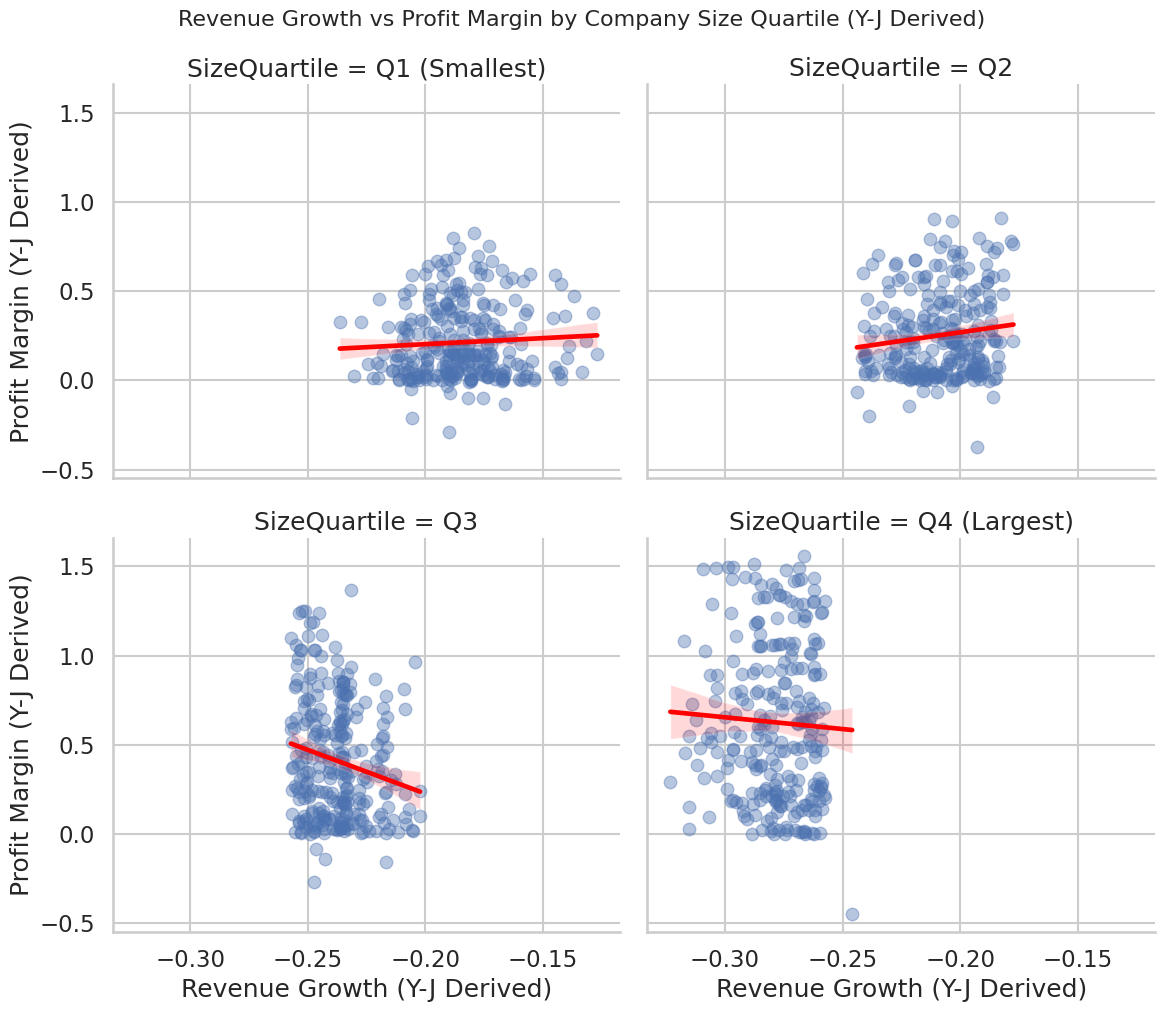

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create faceted lmplot by SizeQuartile
g = sns.lmplot(
    data=df,
    x='Growth_yj_derived',
    y='ProfitMargin_yj_derived',
    col='SizeQuartile',
    col_wrap=2,
    height=5,
    aspect=1.2,
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

# Set informative labels and title
g.set_axis_labels('Revenue Growth (Y-J Derived)', 'Profit Margin (Y-J Derived)')
g.fig.suptitle('Revenue Growth vs Profit Margin by Company Size Quartile (Y-J Derived)', y=1.02, fontsize=16)

plt.show()

In [ ]:
import pandas as pd

# 1. Create 'GrowthBin' by dividing 'Growth' into 4 quartiles
df['GrowthBin'] = pd.qcut(df['Growth'], 4, labels=['G1 (Low)', 'G2', 'G3', 'G4 (High)'])

# 2. Group by SizeQuartile and GrowthBin and calculate mean ProfitMargin
# 3. Pivot the result into a table
summary_table = df.groupby(['SizeQuartile', 'GrowthBin'], observed=True)['ProfitMargin'].mean().unstack()

# 4. Print the resulting summary table
print("--- Summary Table: Mean Profit Margin by Size and Growth Quartiles ---")
display(summary_table.style.format('{:.4f}').background_gradient(cmap='RdYlGn'))

# 5. Brief observation
print("\nObservation: Compare mean margins across GrowthBins within each SizeQuartile to identify trade-offs.")

KeyError: 'Growth'